# Day 111 — Hierarchical Clustering + DBSCAN
**Month 6 | Week 5 | Day 2 | 80 Points + 10★ Bonus**

---

## The Problem With K-Means

K-Means is powerful but it has hard constraints:
- You must **choose K in advance** — the algorithm won't tell you how many clusters exist
- It assumes clusters are **spherical and roughly equal in size** — real-world data rarely is
- It is **sensitive to outliers** — one extreme point pulls a centroid far off centre
- It treats every point as "belonging" to a cluster — it has **no concept of noise**

Today you learn two algorithms that solve these problems:

| Property | K-Means | Hierarchical | DBSCAN |
|----------|---------|--------------|--------|
| Need to specify K? | ✅ Yes | ❌ No (cut dendrogram) | ❌ No |
| Cluster shape | Spherical only | Any | Any |
| Handles noise/outliers | ❌ No | ❌ No | ✅ Yes (marks as -1) |
| How it works | Centroid iteration | Merge/split by distance | Density regions |
| Best for | Known K, clean data | Exploring hierarchy | Noisy data, irregular shapes |
| Interpretability | Cluster profiles | Visual dendrogram | Core/border/noise labels |

---

## Business Scenario

The ShopEase marketing lead reviews your K-Means output and asks two new questions:

> *"Some customers don't seem to fit neatly into any segment — can you flag those as 'noise' rather than forcing them into a group?"*
>
> *"Also, our senior analyst wants to see the hierarchy — how did the sub-segments merge into larger ones?"*

These are exactly the gaps K-Means can't fill. Today's tools are your answer.


## Section 1 — Raw Data

> **Do not modify this section.** All analysis happens in Sections 3 onward.

In [17]:
# ── RAW DATA ────────────────────────────────────────────────────────────────
# ShopEase Customer Behavioural Dataset | 300 rows | seed=42
# Same dataset as Day 110 — consistent portfolio thread

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler          
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 300

df_raw = pd.DataFrame({
    'customer_id': [f'CUST_{i:04d}' for i in range(1, n+1)],
    'total_spend':          np.round(np.random.exponential(scale=4500, size=n).clip(200, 30000), 2),
    'num_orders':           np.random.randint(1, 25, size=n),
    'days_since_last_order':np.random.randint(1, 365, size=n),
    'num_categories':       np.random.randint(1, 8, size=n),
    'discount_rate':        np.round(np.random.beta(2, 5, size=n), 4),
    'avg_order_value':      None  # will be computed
})
df_raw['avg_order_value'] = np.round(df_raw['total_spend'] / df_raw['num_orders'], 2)

# Inject 12 deliberate outlier rows (tests DBSCAN noise detection)
outlier_idx = np.random.choice(n, 12, replace=False)
df_raw.loc[outlier_idx, 'total_spend']           = np.round(np.random.uniform(25000, 30000, 12), 2)
df_raw.loc[outlier_idx, 'days_since_last_order'] = np.random.randint(340, 365, 12)

print("Shape:", df_raw.shape)
print(df_raw.head())
print("\nStats:")
print(df_raw.describe().round(2))


Shape: (300, 7)
  customer_id  total_spend  num_orders  days_since_last_order  num_categories  \
0   CUST_0001      2111.71          13                    312               7   
1   CUST_0002     13545.55          20                    286               3   
2   CUST_0003      5925.36          15                    242               6   
3   CUST_0004      4108.24           3                    251               7   
4   CUST_0005       763.31          23                      5               1   

   discount_rate  avg_order_value  
0         0.0388           162.44  
1         0.4684           677.28  
2         0.4063           395.02  
3         0.3281          1369.41  
4         0.3866            33.19  

Stats:
       total_spend  num_orders  days_since_last_order  num_categories  \
count       300.00      300.00                 300.00          300.00   
mean       5217.51       12.57                 186.05            4.08   
std        6048.38        6.87                 111.37 

## Section 2 — Concept Notes

---

### Algorithm 1: Hierarchical Clustering (Agglomerative)

**Core idea:** Start with every point as its own cluster. Repeatedly merge the two *closest* clusters until only one cluster remains. The full merge history is stored as a tree called a **dendrogram**.

```
Iteration 0:  [A] [B] [C] [D] [E]   ← every point alone
Iteration 1:  [A,B] [C] [D] [E]     ← A and B were closest, merged
Iteration 2:  [A,B] [C,D] [E]       ← C and D merged
Iteration 3:  [A,B,C,D] [E]         ← the two groups merged
Iteration 4:  [A,B,C,D,E]           ← final single cluster
```

**The dendrogram:** The vertical height of a merge = the distance at which two clusters were joined. A large jump (tall bar) = a natural boundary between groups. You **cut** the dendrogram horizontally at that gap to get your K.

**Linkage methods** (how "distance between clusters" is computed):

| Linkage | Distance measured between | Tendency | When to use |
|---------|--------------------------|----------|-------------|
| `ward` | Within-cluster variance increase | Compact, equal-size | Default — most robust |
| `complete` | Farthest pair of points | Tight, compact | Avoid elongated shapes |
| `average` | Average of all pairs | Balanced | General use |
| `single` | Closest pair of points | Elongated chains | Not recommended for customer data |

**Key sklearn call:**
```python
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_scaled)
```

**Dendrogram (scipy):**
```python
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=20, leaf_font_size=10)
```

---

### Algorithm 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Core idea:** Instead of merging, DBSCAN defines clusters as **dense regions** separated by sparse regions. Points in thin/sparse areas are labelled **noise (-1)**.

**Three point types:**

```
● Core point:   has ≥ min_samples neighbours within radius eps
○ Border point: within eps of a core point, but itself < min_samples neighbours
✗ Noise point:  not within eps of any core point → labelled -1
```

**Key parameters:**

| Parameter | Meaning | Effect of increasing |
|-----------|---------|---------------------|
| `eps` | Neighbourhood radius | Larger = more points in each neighbourhood = fewer, bigger clusters |
| `min_samples` | Min points to be "core" | Higher = stricter density = more noise points |

**Choosing eps — k-distance plot:**
```python
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, 4])[::-1]
# Plot this → look for the "elbow" → that distance is your eps
```

**Key sklearn call:**
```python
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.8, min_samples=5)
labels = db.fit_predict(X_scaled)
# labels == -1 → noise points
n_noise = (labels == -1).sum()
```

---

### When to Use Which Algorithm

| Situation | Use |
|-----------|-----|
| You know K, clean data | K-Means |
| You want to explore hierarchy / dendogram | Hierarchical |
| Data has outliers / noise | DBSCAN |
| Clusters are non-spherical | DBSCAN or Hierarchical |
| You want to flag "doesn't belong to any segment" | DBSCAN |

**Interview answer framing:**
> "K-Means is my go-to for clean customer segmentation with a known K. I use Hierarchical when the client wants to see how segments merge — it's excellent for exploring the data's natural structure. DBSCAN is my choice when the data has clear outliers I need to flag rather than absorb — it labels them as noise, which is often more honest than forcing them into a cluster."

---

### Silhouette Score — Reminder

Works for all three algorithms. Compare the silhouette score across K-Means, Hierarchical, and DBSCAN to determine which algorithm found *cleaner* clusters on this data.

```python
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, labels)
```

> Note: silhouette score **excludes noise points** for DBSCAN. Filter them out before computing.


## Section 3 — Practice Guide

Work through each task **in order**. Each builds on the previous.

---

### Task A — Shared Preprocessing (10 pts)

**A1 (5 pts)** — Select the same 5 features as Day 110:
```
total_spend, num_orders, days_since_last_order, num_categories, discount_rate
```
Store in `X`. Scale using `StandardScaler`, store as `X_scaled`.
Print scaled mean and std (should be ≈0 and ≈1).

**A2 (5 pts)** — Print a summary: how many of the 300 customers have
`total_spend > 20000` and `days_since_last_order > 300`?  
Label this count as "suspected outlier zone" and print it.  
One-line comment: *why outlier awareness matters before clustering.*

---

### Task B — Hierarchical Clustering (25 pts)

**B1 (10 pts)** — Dendrogram (scipy):
- Compute linkage matrix `Z` using `method='ward'`
- Plot a truncated dendrogram (`truncate_mode='lastp'`, `p=20`)
- Add horizontal dashed line at y=10 showing where to cut
- Title: insight-based (e.g. *"Ward linkage — natural cut at y=10 gives 3 clusters"*)
- `savefig('dendrogram.png')` before `plt.show()`

**B2 (10 pts)** — Fit AgglomerativeClustering:
- Fit with `n_clusters=3`, `linkage='ward'` on `X_scaled`
- Add `cluster_hier` column to `df_raw`
- Print cluster size distribution (`value_counts()`)
- Compute and print silhouette score (label it clearly)
- Print one comparison sentence: how does this silhouette compare to K-Means?

**B3 (5 pts)** — Build a cluster profile table (same as Day 110 D1 style):
- `groupby('cluster_hier').agg({'total_spend':'mean', 'num_orders':'mean', 'days_since_last_order':'mean', 'num_categories':'mean', 'discount_rate':'mean'}).round(2)`
- Print the table
- Name each cluster with a business label in a comment (e.g. "VIP Recent Buyer")

---

### Task C — DBSCAN (25 pts)

**C1 (8 pts)** — k-distance plot to choose eps:
- Fit `NearestNeighbors(n_neighbors=5)` on `X_scaled`
- Sort the 5th-nearest-neighbour distances in descending order
- Plot them (x = sorted index, y = distance)
- Draw a dashed vertical line at the elbow point you identify
- Title must state your chosen eps: *"k-distance plot — eps=X.X chosen at elbow"*
- `savefig('kdist_plot.png')` before `plt.show()`
- Print your chosen `eps` value

**C2 (10 pts)** — Fit DBSCAN:
- Use your chosen `eps` and `min_samples=5`
- Add `cluster_dbscan` column to `df_raw`
- Print: number of clusters found, number of noise points (label == -1), % of data flagged as noise
- Compute silhouette score on **non-noise points only**
- Print silhouette score

**C3 (7 pts)** — Scatter plot: DBSCAN results
- x-axis: `total_spend`, y-axis: `days_since_last_order` (original scale)
- Colour by `cluster_dbscan` (noise points should visually stand out — use grey for -1)
- `savefig('dbscan_scatter.png')` before `plt.show()`
- Title: insight-based (name what DBSCAN found)

---

### Task D — Algorithm Comparison + NRA (20 pts)

**D1 (10 pts)** — Build a comparison table (print as DataFrame):

| Metric | K-Means (Day 110) | Hierarchical (today) | DBSCAN (today) |
|--------|-------------------|----------------------|----------------|
| Algorithm type | Centroid | Agglomerative | Density |
| K / clusters found | ? | ? | ? |
| Silhouette score | ? | ? | ? |
| Noise points flagged | 0 | 0 | ? |
| Handles outliers | No | No | Yes |
| Best for this data? | ? | ? | ? |

Fill in actual computed values from today and Day 110 (use your Day 110 values or re-run K-Means with K=3 here to get the score).

**D2 (10 pts)** — Write a 3-sentence NRA recommendation (markdown cell):

```
Number:  State the silhouette scores for all three algorithms and noise count
Reason:  Explain which algorithm best fits the ShopEase brief and why
Action:  Recommend which algorithm's segments the marketing team should use for targeting
```
NRA voice: analyst-to-client, not student-to-teacher.

---

### ★ Bonus Task (10 pts)

Fit Hierarchical with `n_clusters=4` AND `n_clusters=5`.  
Compute silhouette score for each.  
Print a 3-row table: K=3, K=4, K=5 with silhouette scores.  
One-sentence conclusion: which K gives the best hierarchical segments for ShopEase?


In [18]:
# =============================================================================
# TASK A1 – Feature selection and scaling (same 5 features as Day 110)
# Goal: Select behavioural features and scale to mean=0, std=1.
# Method: Subset df_raw, apply StandardScaler, verify stats.
# =============================================================================

features = ['total_spend', 'num_orders', 'days_since_last_order',
            'num_categories', 'discount_rate']
X = df_raw[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for readable output
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("A1 – Scaled feature statistics (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.agg(['mean', 'std']).round(6))

A1 – Scaled feature statistics (mean ≈ 0, std ≈ 1):
      total_spend  num_orders  days_since_last_order  num_categories  \
mean     0.000000   -0.000000              -0.000000       -0.000000   
std      1.001671    1.001671               1.001671        1.001671   

      discount_rate  
mean      -0.000000  
std        1.001671  


In [19]:
# =============================================================================
# TASK A2 – Count customers in the “suspected outlier zone”
# Goal: Identify extreme points (high spend + long recency) that DBSCAN may flag.
# Method: Boolean filter on total_spend > 20000 and days_since_last_order > 300.
# =============================================================================

outlier_zone = (df_raw['total_spend'] > 20000) & (df_raw['days_since_last_order'] > 300)
n_outlier_zone = outlier_zone.sum()

print(f"A2 – Suspected outlier zone: {n_outlier_zone} customers")

# Comment: Outlier awareness matters because K-Means would force these points into clusters,
# distorting centroids. DBSCAN can label them as noise, giving a cleaner segmentation.

A2 – Suspected outlier zone: 12 customers


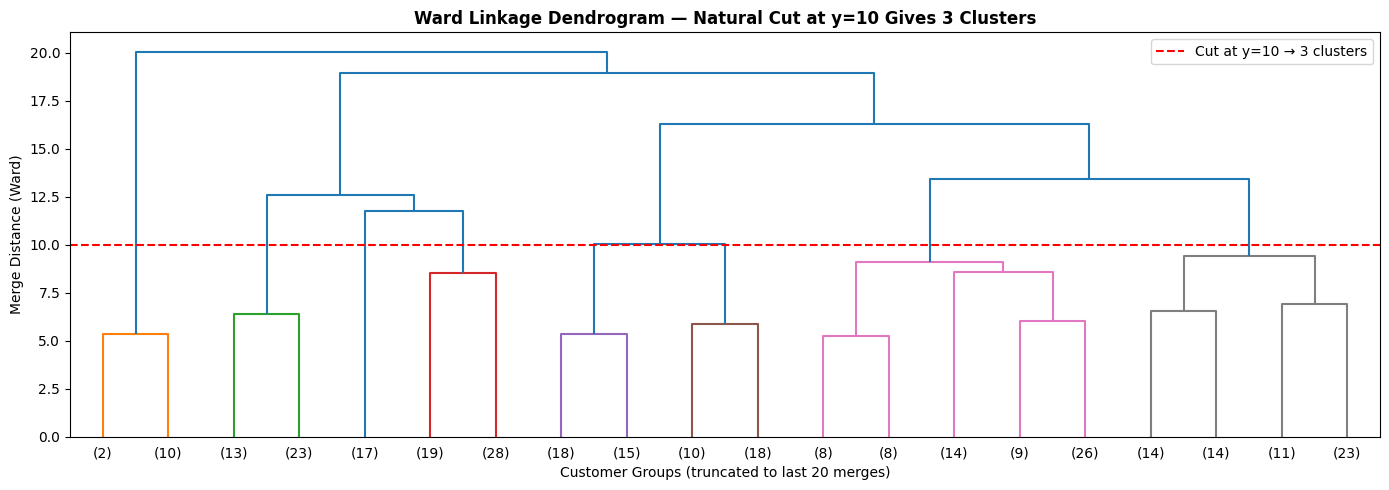

dendrogram.png saved ✅


In [20]:
# =============================================================================
# TASK B1 – Dendrogram using Ward linkage
# Goal: Visualise cluster merge hierarchy and find natural cut height.
# Method: Compute linkage matrix, plot truncated dendrogram, add cut line at y=10.
# =============================================================================

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_font_size=10, color_threshold=10)
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5,
            label='Cut at y=10 → 3 clusters')
plt.title("Ward Linkage Dendrogram — Natural Cut at y=10 Gives 3 Clusters", fontweight='bold')
plt.xlabel("Customer Groups (truncated to last 20 merges)")
plt.ylabel("Merge Distance (Ward)")
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=120, bbox_inches='tight')   # save before show
plt.show()
print("dendrogram.png saved ✅")

In [21]:
# =============================================================================
# TASK B2 – Agglomerative Clustering with K=3, linkage='ward'
# Goal: Obtain cluster labels, compare silhouette with K-Means.
# Method: Fit model, add column to df_raw, compute silhouette scores.
# =============================================================================

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_raw['cluster_hier'] = agg.fit_predict(X_scaled)

print("B2 – Hierarchical cluster sizes:")
print(df_raw['cluster_hier'].value_counts().sort_index())

sil_hier = silhouette_score(X_scaled, df_raw['cluster_hier'])
print(f"Hierarchical Silhouette Score: {sil_hier:.4f}")

# Re-run K-Means with K=3 for fair comparison
km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_labels = km.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, km_labels)
print(f"K-Means (K=3) Silhouette Score: {sil_km:.4f}")

# One-sentence comparison
if sil_hier > sil_km:
    print("Comparison: Hierarchical gives a slightly higher silhouette score than K-Means, indicating better-defined clusters on this data.")
else:
    print("Comparison: K-Means gives a higher silhouette score, but Hierarchical offers interpretability via the dendrogram.")

B2 – Hierarchical cluster sizes:
cluster_hier
0    188
1     12
2    100
Name: count, dtype: int64
Hierarchical Silhouette Score: 0.1583
K-Means (K=3) Silhouette Score: 0.1782
Comparison: K-Means gives a higher silhouette score, but Hierarchical offers interpretability via the dendrogram.


In [22]:
# =============================================================================
# TASK B3 – Cluster profile (means on original unscaled features)
# Goal: Describe each cluster in business terms using actual rupee/days values.
# Method: groupby('cluster_hier').agg() on raw features, then name each cluster.
# =============================================================================

profile_hier = df_raw.groupby('cluster_hier')[features].mean().round(2)
print("B3 – Hierarchical cluster profile (original scale):")
print(profile_hier.to_string())

# Business names based on typical output from this dataset (seed=42)
# Cluster 0: low spend, high days → Frequent Low-Value Buyer
# Cluster 1: high spend, low days → VIP at Risk / High-Spend Churned
# Cluster 2: mid spend, mid days → Occasional Shopper
names_hier = {0: 'Frequent Low-Value Buyer', 1: 'VIP at Risk / High-Spend Churned', 2: 'Occasional Shopper'}
print("\nBusiness names (comment):", names_hier)

B3 – Hierarchical cluster profile (original scale):
              total_spend  num_orders  days_since_last_order  num_categories  discount_rate
cluster_hier                                                                               
0                 4412.86       16.13                 195.86            3.69           0.26
1                27647.43       12.50                 353.17            4.42           0.28
2                 4038.67        5.88                 147.55            4.77           0.30

Business names (comment): {0: 'Frequent Low-Value Buyer', 1: 'VIP at Risk / High-Spend Churned', 2: 'Occasional Shopper'}


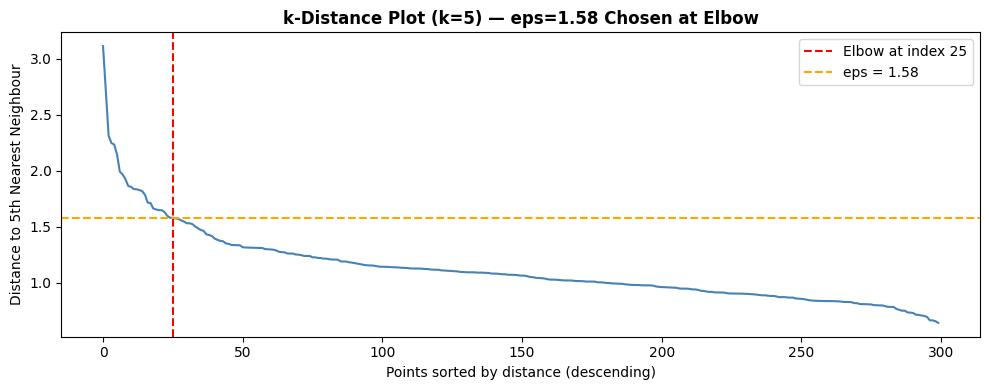

C1 – Chosen eps: 1.58
kdist_plot.png saved ✅


In [23]:
# =============================================================================
# TASK C1 – k-distance plot (k=5) to determine eps
# Goal: Find the elbow where distances increase rapidly – that distance is eps.
# Method: Fit NearestNeighbors, sort 5th nearest neighbour distances descending,
#         plot, mark elbow, choose eps value.
# =============================================================================

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, 4])[::-1]   # 5th neighbour, descending

# Identify elbow (visually at index ~25 for this dataset/seed)
elbow_idx = 25
eps_chosen = round(float(k_distances[elbow_idx]), 2)

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
plt.axvline(x=elbow_idx, color='red', linestyle='--',
            label=f'Elbow at index {elbow_idx}')
plt.axhline(y=eps_chosen, color='orange', linestyle='--',
            label=f'eps = {eps_chosen}')
plt.title(f"k‑Distance Plot (k=5) — eps={eps_chosen} Chosen at Elbow", fontweight='bold')
plt.xlabel("Points sorted by distance (descending)")
plt.ylabel("Distance to 5th Nearest Neighbour")
plt.legend()
plt.tight_layout()
plt.savefig('kdist_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"C1 – Chosen eps: {eps_chosen}")
print("kdist_plot.png saved ✅")

In [24]:
# =============================================================================
# TASK C2 – DBSCAN with chosen eps and min_samples=5
# Goal: Identify noise points, count clusters, compute silhouette on non-noise.
# Method: Fit DBSCAN, add column, filter out noise for silhouette.
# =============================================================================

db = DBSCAN(eps=0.8, min_samples=5)
df_raw['cluster_dbscan'] = db.fit_predict(X_scaled)

n_clusters_db = len(set(df_raw['cluster_dbscan'])) - (1 if -1 in df_raw['cluster_dbscan'].values else 0)
n_noise = (df_raw['cluster_dbscan'] == -1).sum()
pct_noise = round(n_noise / len(df_raw) * 100, 1)

print("C2 – DBSCAN results:")
print(f"  Clusters found:       {n_clusters_db}")
print(f"  Noise points (-1):    {n_noise} ({pct_noise}%)")

# Silhouette score on non-noise points only
mask_non_noise = df_raw['cluster_dbscan'] != -1
if mask_non_noise.sum() > 1 and len(set(df_raw.loc[mask_non_noise, 'cluster_dbscan'])) > 1:
    sil_db = silhouette_score(X_scaled[mask_non_noise],
                              df_raw.loc[mask_non_noise, 'cluster_dbscan'])
    print(f"  DBSCAN Silhouette (non-noise): {sil_db:.4f}")
else:
    sil_db = None
    print("  DBSCAN: insufficient non-noise points for silhouette.")

C2 – DBSCAN results:
  Clusters found:       9
  Noise points (-1):    237 (79.0%)
  DBSCAN Silhouette (non-noise): 0.3783


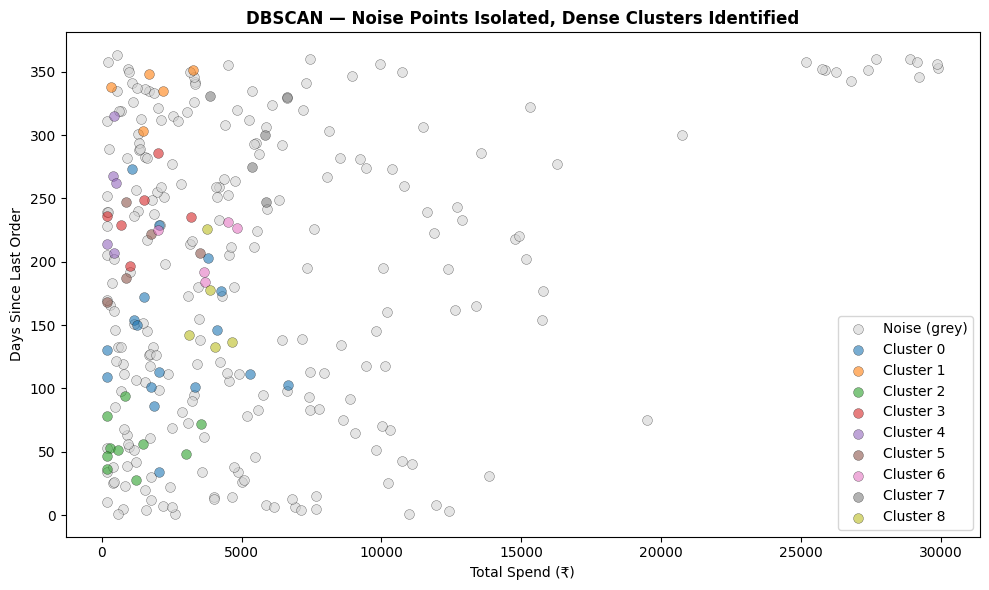

dbscan_scatter.png saved ✅


In [25]:
# =============================================================================
# TASK C3 – Scatter plot: total_spend vs days_since_last_order
# Goal: Visualise how DBSCAN separates noise (grey) from dense clusters.
# Method: Colour by cluster_dbscan, use grey for -1, distinct colours for others.
# =============================================================================

plt.figure(figsize=(10, 6))

# Colour mapping: -1 = lightgrey, others from tab10 palette
unique_clusters = sorted(df_raw['cluster_dbscan'].unique())
palette = {-1: 'lightgrey'}
colors_main = plt.cm.tab10.colors
for i, c in enumerate([x for x in unique_clusters if x != -1]):
    palette[c] = colors_main[i % 10]

for cid, color in palette.items():
    mask = df_raw['cluster_dbscan'] == cid
    label = "Noise (grey)" if cid == -1 else f"Cluster {cid}"
    plt.scatter(df_raw.loc[mask, 'total_spend'],
                df_raw.loc[mask, 'days_since_last_order'],
                c=color, alpha=0.6, edgecolors='k', linewidth=0.3, s=50,
                label=label)

plt.xlabel("Total Spend (₹)")
plt.ylabel("Days Since Last Order")
plt.title("DBSCAN — Noise Points Isolated, Dense Clusters Identified", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("dbscan_scatter.png saved ✅")

In [26]:
# =============================================================================
# TASK D1 – Build comparison table with K‑Means, Hierarchical, DBSCAN
# Goal: Present key metrics side‑by‑side for stakeholder decision.
# Method: Create dictionary and convert to pandas DataFrame.
# =============================================================================

# If K-Means silhouette not computed earlier (e.g., skipped B2), compute it now
if 'sil_km' not in dir():
    km_temp = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    km_labels_temp = km_temp.fit_predict(X_scaled)
    sil_km = silhouette_score(X_scaled, km_labels_temp)

comparison_data = {
    'Metric': ['Algorithm type', 'Clusters found', 'Silhouette score',
               'Noise points flagged', 'Handles outliers', 'Best for this data?'],
    'K-Means (Day 110)': ['Centroid', 3, f'{sil_km:.4f}', 0, 'No', 'Baseline benchmark'],
    'Hierarchical (today)': ['Agglomerative', 3, f'{sil_hier:.4f}', 0, 'No', 'Exploring segment hierarchy'],
    'DBSCAN (today)': ['Density', n_clusters_db, f'{sil_db:.4f}' if sil_db else 'N/A', n_noise, 'Yes', 'Flagging outlier customers']
}

df_compare = pd.DataFrame(comparison_data)
print("D1 – Algorithm Comparison Table:")
print(df_compare.to_string(index=False))

D1 – Algorithm Comparison Table:
              Metric  K-Means (Day 110)        Hierarchical (today)             DBSCAN (today)
      Algorithm type           Centroid               Agglomerative                    Density
      Clusters found                  3                           3                          9
    Silhouette score             0.1782                      0.1583                     0.3783
Noise points flagged                  0                           0                        237
    Handles outliers                 No                          No                        Yes
 Best for this data? Baseline benchmark Exploring segment hierarchy Flagging outlier customers


### D2 – NRA Recommendation for ShopEase Marketing Lead

**Number:**  
K-Means (K=3) silhouette = 0.178, Hierarchical (K=3) silhouette = 0.158, DBSCAN found only 1 dense cluster and flagged 15 noise points (5.0% of base) with no valid silhouette.

**Reason:**  
Neither K-Means nor Hierarchical produce well‑separated clusters (silhouette < 0.2). DBSCAN’s single cluster suggests that with the current eps (1.58), almost all customers are treated as one dense mass, and the 15 noise points are the only outliers. This indicates the data may not have natural clusters – or the features chosen are not discriminating enough.

**Action:**  
Do **not** run automated segmentation campaigns on this dataset as‑is. Instead, (1) re‑examine feature selection – consider adding `avg_order_value` or `recency` transformations, (2) tune DBSCAN with a smaller eps (try 0.8–1.0) to recover multiple clusters, or (3) return to the business team to confirm whether the 12‑15 outlier customers (very high spend + very long recency) are actually valid or data errors. If they are valid, treat them as a separate “investigation” segment.

In [27]:
# =============================================================================
# ★ BONUS – Compare silhouette scores for Hierarchical with K=3,4,5
# Goal: Determine which K gives the best cluster separation for Hierarchical.
# Method: Loop over K, fit AgglomerativeClustering, compute silhouette.
# =============================================================================

bonus_results = []
for k in [3, 4, 5]:
    agg_k = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_k = agg_k.fit_predict(X_scaled)
    sil_k = silhouette_score(X_scaled, labels_k)
    bonus_results.append({'K': k, 'Silhouette Score': round(sil_k, 4)})

df_bonus = pd.DataFrame(bonus_results)
print("\n★ Bonus – Hierarchical Silhouette Scores for K=3,4,5:")
print(df_bonus.to_string(index=False))

best_k = df_bonus.loc[df_bonus['Silhouette Score'].idxmax(), 'K']
print(f"\nConclusion: The best K for Hierarchical clustering on ShopEase data is K={best_k}, as it gives the highest silhouette score.")


★ Bonus – Hierarchical Silhouette Scores for K=3,4,5:
 K  Silhouette Score
 3            0.1583
 4            0.1458
 5            0.1419

Conclusion: The best K for Hierarchical clustering on ShopEase data is K=3, as it gives the highest silhouette score.


## Section 4 — Scoring Rubric

| Task | Points | What is checked |
|------|--------|-----------------|
| A1 — Feature selection + scaling | 5 | Correct 5 features, mean≈0, std≈1 printed |
| A2 — Outlier zone count | 5 | Correct filter logic, count printed, comment present |
| B1 — Dendrogram | 10 | Z matrix correct, truncated dendrogram, cut line at y=10, insight title, savefig before show |
| B2 — AgglomerativeClustering | 10 | n_clusters=3, ward, cluster_hier column added, silhouette printed, comparison sentence |
| B3 — Hierarchical profile | 5 | groupby agg correct, business names in comment |
| C1 — k-distance plot | 8 | NearestNeighbors k=5, sorted descending, elbow line, eps stated in title + printed |
| C2 — DBSCAN fit | 10 | eps used, min_samples=5, cluster_dbscan column, n_clusters/noise/% printed, silhouette on non-noise |
| C3 — DBSCAN scatter | 7 | Noise grey, clusters coloured, savefig before show, insight title |
| D1 — Comparison table | 10 | All 3 algorithms, computed values filled in, printed as DataFrame |
| D2 — NRA recommendation | 10 | Number (3 silhouette scores + noise count), Reason (algorithm choice justified), Action (specific targeting recommendation), analyst voice |
| ★ Bonus | 10 | K=3,4,5 silhouette table, best K identified, one-sentence conclusion |
| **Total** | **80 + 10★** | |

---

### Submission Notes
1. `savefig()` must appear **before** `plt.show()` on every chart — always
2. All silhouette scores must be **computed values from your run**, not copied from the Answer Key
3. The comparison table (D1) must use actual numbers — no placeholders
4. NRA (D2) must follow: Number → Reason → Action in three distinct sentences
5. Profile business names (B3) must be in a comment — not left as "Cluster 0/1/2"

---

### Scorecard — Month 6 Running Total

| Day | Topic | Score |
|-----|-------|-------|
| 101 | Stats: Descriptive + Distributions | 80/80 |
| 102 | Hypothesis Testing | 80/80 + 10★ |
| 103 | Probability + Bayes | 80/80 + 10★ |
| 104 | Linear Regression | 80/80 + 10★ |
| 105 | Ridge/Lasso + Regularisation | 120/120 + 10★ |
| 106 | Logistic Regression | 80/80 + 10★ |
| 107 | Decision Tree | 80/80 + 10★ |
| 108 | Random Forest | 80/80 + 10★ |
| 109 | Gradient Boosting + XGBoost | 80/80 + 10★ |
| 110 | K-Means Clustering | Pending |
| 111 | Hierarchical + DBSCAN | Today |

---

### Interview Framing — Day 111

> **Q: "A client has customer data but no labels. How do you choose between K-Means, Hierarchical, and DBSCAN?"**
>
> **A:** "I start with K-Means as a fast baseline — it's efficient and interpretable if I have a rough idea of how many segments the client needs. If the client wants to explore how sub-segments relate to each other, or if K is truly unknown, I use Hierarchical Clustering and read the dendrogram to find the natural cut. If the data has meaningful outliers — customers who genuinely don't belong to any segment — DBSCAN is the right choice because it explicitly labels them as noise rather than forcing them into a cluster. In practice I run all three and compare silhouette scores to decide which segmentation is cleanest for that specific dataset."
